# PGR107 Python Programming – Home Examination Spring 2026

This notebook contains solutions to all five exam tasks.
All code is written in Python and structured with markdown explanations before and after each task.

**Submission format:** `.ipynb` (Jupyter Notebook)  
**Language:** English (consistent throughout)

In [1]:
# Global imports used across the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random as rnd
import math
import statistics

%matplotlib inline

---
## Task 1 – Supernacci (15 points)

### What we need to do
We implement the fictional Supernacci sequence defined as:
- `s(1) = 1`
- `s(n)` = sum of the last `(n-1) % 3` Supernacci numbers, or `s(n-1)` if that sum would be empty (i.e., `(n-1) % 3 == 0`).

### Strategy
We build the sequence iteratively (no recursion, as required) using a list and **slicing**.
- At each step `i`, we compute `k = (i-1) % 3` — this is how many previous terms to sum.
- If `k == 0`, the sum is empty, so we repeat the previous value.
- Otherwise we use `s[-k:]` to slice the last `k` elements and call `sum()` on them.

**Why slicing?** Negative-index slicing `s[-k:]` always gives us the last `k` elements without knowing the list length — elegant and efficient.

In [2]:
def supernacci(n):
    """
    Computes the n-th Supernacci number iteratively using slicing.

    Parameters:
        n (int): The position in the Supernacci sequence (1-indexed).
    Returns:
        int: The n-th Supernacci number.
    """
    s = [1]  # Base case: s(1) = 1

    for i in range(2, n + 1):
        k = (i - 1) % 3  # Number of preceding terms to sum
        if k == 0:
            # (i-1) is divisible by 3 → empty sum → repeat previous value
            s.append(s[-1])
        else:
            # Sum the last k elements using slicing
            s.append(sum(s[-k:]))

    return s[n - 1]  # Return 0-indexed value for 1-indexed n


# --- Test the function ---
print('Supernacci sequence for n=1..12:')
for n in range(1, 13):
    print(f'  s({n}) = {supernacci(n)}')

Supernacci sequence for n=1..12:
  s(1) = 1
  s(2) = 1
  s(3) = 2
  s(4) = 2
  s(5) = 2
  s(6) = 4
  s(7) = 4
  s(8) = 4
  s(9) = 8
  s(10) = 8
  s(11) = 8
  s(12) = 16


### Interpretation of results

The pattern cycles with period 3:
- When `(n-1) % 3 == 1`: sum the 1 most recent term → same as the previous value.
- When `(n-1) % 3 == 2`: sum the 2 most recent terms → the sequence doubles every third step.
- When `(n-1) % 3 == 0`: empty sum → carry forward the previous value.

This produces groups of three equal values that double each group: 1, 1, 2, 2, 2, 4, 4, 4, 8, 8, 8, 16, …

No recursion is used anywhere — all values are built up in the list `s` with a single `for` loop.

---
## Task 2 – Debug the Dice Game (17 points)

### What we need to do
The gambler's code has **multiple bugs**. We identify each one, explain it, and provide the corrected version.

### Bug Analysis

| # | Location | Bug | Fix |
|---|----------|-----|-----|
| 1 | `getDiceGuess()` | Variable named `guesss` (extra `s`) — a different variable from `guess`, always holds its initial value `0` | Rename to `guess` consistently |
| 2 | `getDiceGuess()` | `while guesss not in ('1 ','2 ','3 ','4 ')` — trailing spaces; user input will never match | Use integers `(1, 2, 3, 4)` |
| 3 | `getDiceGuess()` | `return guesss` — returns the uninitialized typo variable (value `0`), not the actual guess | `return guess` |
| 4 | `getDiceGuess()` | `guess = input()` — `input()` returns a string, but `dice` is an int; comparison always fails | `guess = int(input())` |
| 5 | `rollDice()` | `random.randint(1, 5)` — `random` is not defined (imported as `rnd`); upper bound should be 4 | `rnd.randint(1, 4)` |
| 6 | `rollDice()` | `if dice = guess:` — assignment `=` instead of equality `==` (appears 3 times) | `if dice == guess:` |
| 7 | `rollDice()` | `if dice = guess` (last occurrence) — missing colon `:` at end of `if` statement | Add `:` |
| 8 | `rollDice()` | `guess` and `guesss` used interchangeably — inconsistent naming breaks logic | Use `guess` everywhere |
| 9 | `rollDice()` | Raw `input()` calls return strings; comparing against integer `dice` always `False` | Wrap all `input()` with `int()` |
| 10 | `rollDice()` | Guesses 2–4 use raw `input()` — no validation, player can enter invalid numbers | Route all guesses through `getDiceGuess()` |

In [3]:
# --- FIXED CODE ---

import random as rnd  # Alias is rnd, not random (Fix #5)


def getDiceGuess(prompt='Guess the number on a 4-sided dice! Enter a number between 1 and 4:'):
    """
    Asks the user to guess a number between 1 and 4.
    Loops until a valid integer in range [1, 4] is entered.
    Returns the guess as an integer.
    """
    guess = 0  # Fix #1/#8: consistent variable name 'guess' (not 'guesss')
    while guess not in (1, 2, 3, 4):  # Fix #2: compare ints, not strings with trailing spaces
        print(prompt)
        try:
            guess = int(input())  # Fix #4: convert input string to int
        except ValueError:
            print('Please enter a whole number.')  # Graceful handling of non-numeric input
    return guess  # Fix #3: return 'guess', not 'guesss'


def rollDice():
    """
    Rolls a 4-sided die and gives the player up to 4 validated guesses.
    """
    dice = rnd.randint(1, 4)  # Fix #5: use alias 'rnd', range 1-4 (not 1-5)

    # Guess 1
    guess = getDiceGuess('Guess 1 - Enter a number between 1 and 4:')  # Fix #10: validated
    if dice == guess:  # Fix #6: == not =
        print('You are good!')
        return

    print('Sorry! Try to guess again!')

    # Guess 2
    guess = getDiceGuess('Guess 2 - Enter a number between 1 and 4:')  # Fix #9/#10
    if dice == guess:  # Fix #6
        print('Congrats! You got it!')
        return

    print('Sorry! Your third chance!')

    # Guess 3
    guess = getDiceGuess('Guess 3 - Enter a number between 1 and 4:')  # Fix #9/#10
    if dice == guess:  # Fix #6
        print('Congrats! You got it!')
        return

    print('Sorry! You still can try!')

    # Guess 4
    guess = getDiceGuess('Guess 4 (final) - Enter a number between 1 and 4:')  # Fix #9/#10
    if dice == guess:  # Fix #6/#7: == and colon present
        print('Congrats! You got it!')
    else:
        print(f'Nope. You are really bad at this game. The number was {dice}.')


# Uncomment to play interactively:
# rollDice()
print('Dice game functions defined. Call rollDice() to play.')

Dice game functions defined. Call rollDice() to play.


### Summary of all bugs found and fixed

1. **Typo `guesss`** – extra `s` created a separate variable always holding `0`.
2. **String comparison with trailing spaces** – `'1 '` will never match what a user types.
3. **`return guesss`** – returned the typo variable (value `0`) instead of the actual guess.
4. **`input()` not converted to `int`** – comparing a string to an integer always evaluates to `False`.
5. **`random.randint(1, 5)`** – wrong module name (should be `rnd`) and wrong upper bound (1-4 for a 4-sided die).
6. **`if dice = guess:`** – assignment operator `=` used in condition; must be `==` (3 occurrences).
7. **Missing colon** – last `if dice = guess` had no `:` at the end.
8. **Inconsistent variable names** – `guess` and `guesss` mixed; unified to `guess`.
9. **Type mismatch** – `input()` returns `str`; `dice` is `int`; all inputs converted with `int()`.
10. **No input validation for guesses 2-4** – bare `input()` calls bypassed `getDiceGuess()`; now all four guesses go through the validated function, preventing invalid entries.

---
## Task 3 – Dictionaries and Geography (30 points)

### Overview
We work with two dictionaries:
- `cities`: city name → `[lat, lon, size_km]`
- `poi`: `(lat, lon)` → `[name, rating]`

Distance approximations used throughout:
- 1° latitude ≈ 111 km
- 1° longitude ≈ 68 km

We define a helper `distance_sq()` that computes **squared distance** in km² — sufficient for comparisons and sorting (avoids unnecessary `sqrt()`).

In [4]:
# --- Input data ---

cities = {
    'Bergen':     [60.364098, 5.404422,  15],
    'Oslo':       [59.926959, 10.779454, 10],
    'Trondheim':  [63.433654, 10.390277,  5]
}

poi = {
    (63.426806, 10.396712): ['Nidarosdommen',    4.5],
    (59.926699, 10.701075): ['Vigelandsparken',  5.0],
    (59.907704, 10.753163): ['Operahuset',        4.0],
    (60.397561,  5.322833): ['Bryggen',           4.5],
    (60.387639,  5.321623): ['Universitetmuseet', 5.0],
    (60.342901,  5.336796): ['Gamlehaugen',       4.0]
}


def distance_sq(lat1, lon1, lat2, lon2):
    """
    Returns the squared Euclidean distance (in km^2) between two coordinate pairs.
    Uses flat-Earth approximation: 1 deg lat = 111 km, 1 deg lon = 68 km.
    Squaring avoids sqrt() and is sufficient for min/sort comparisons.
    """
    dlat = (lat1 - lat2) * 111
    dlon = (lon1 - lon2) * 68
    return dlat**2 + dlon**2


print('Data loaded. Helper function defined.')

Data loaded. Helper function defined.


### 3a – Find nearest city and POI

We write two separate functions:
- `closest_city(lat, lon, cities)` — uses `min()` with a `lambda` key over city centers.
- `closest_poi(lat, lon, poi)` — same pattern over POI coordinate keys.

Using `min()` with a `lambda` is clean and Pythonic — avoids manual loop tracking of a minimum.

In [5]:
def closest_city(lat, lon, cities):
    """
    Returns the name of the city closest to (lat, lon).
    """
    return min(
        cities,
        key=lambda city: distance_sq(lat, lon, cities[city][0], cities[city][1])
    )


def closest_poi(lat, lon, poi):
    """
    Returns the name of the POI closest to (lat, lon).
    The keys of 'poi' are (lat, lon) tuples.
    """
    nearest_coords = min(
        poi,
        key=lambda coords: distance_sq(lat, lon, coords[0], coords[1])
    )
    return poi[nearest_coords][0]  # Return name only


# --- User input ---
print('Enter your coordinates to find the nearest city and POI.')
try:
    user_lat = float(input('Enter latitude: '))
    user_lon = float(input('Enter longitude: '))
    print(f'\nNearest city: {closest_city(user_lat, user_lon, cities)}')
    print(f'Nearest POI:  {closest_poi(user_lat, user_lon, poi)}')
except ValueError:
    print('Invalid input. Please enter numeric coordinates.')

Enter your coordinates to find the nearest city and POI.


Enter latitude:  1111111111
Enter longitude:  1111



Nearest city: Trondheim
Nearest POI:  Nidarosdommen


### 3b – Compute city boundaries

Each city is treated as a square. The `size` (in km) is the distance from the center to the farthest point — added and subtracted in each direction.

Conversion from km to degrees:
- `size_lat = size / 111` (km → degrees latitude)
- `size_lon = size / 68`  (km → degrees longitude)

To keep the original `cities` dictionary clean and reusable, `compute_boundaries()` **returns a new dictionary** rather than mutating the input in-place.

In [6]:
def compute_boundaries(cities):
    """
    Returns a new dictionary with each city's data extended by four boundary values:
    [lat, lon, size, north, south, east, west].

    A new dict is returned instead of mutating the input -- safer for reuse.
    """
    cities_bounded = {}
    for city, data in cities.items():
        lat, lon, size = data[0], data[1], data[2]
        size_lat = size / 111  # km to degrees latitude
        size_lon = size / 68   # km to degrees longitude
        cities_bounded[city] = [
            lat, lon, size,
            lat + size_lat,  # north
            lat - size_lat,  # south
            lon + size_lon,  # east
            lon - size_lon   # west
        ]
    return cities_bounded


cities_bounded = compute_boundaries(cities)

print(f"{'City':<12} {'North':>10} {'South':>10} {'East':>10} {'West':>10}")
print('-' * 52)
for city, d in cities_bounded.items():
    lat, lon, size, north, south, east, west = d
    print(f'{city:<12} {north:>10.6f} {south:>10.6f} {east:>10.6f} {west:>10.6f}')

City              North      South       East       West
----------------------------------------------------
Bergen        60.499233  60.228963   5.625010   5.183834
Oslo          60.017049  59.836869  10.926513  10.632395
Trondheim     63.478699  63.388609  10.463806  10.316748


### 3c – Assign POIs to cities

A POI belongs to a city if its coordinates fall within all four boundaries.
We use `cities_bounded` from 3b so boundary values are already available.

In [7]:
def assign_pois_to_cities(cities_bounded, poi):
    """
    Returns a dict mapping each city name to a list of POI coordinate keys
    that fall inside its boundaries.
    Expects cities_bounded to contain [lat, lon, size, north, south, east, west].
    """
    city_pois = {city: [] for city in cities_bounded}

    for coords, info in poi.items():
        poi_lat, poi_lon = coords
        for city, d in cities_bounded.items():
            lat, lon, size, north, south, east, west = d
            if south <= poi_lat <= north and west <= poi_lon <= east:
                city_pois[city].append(coords)

    return city_pois


city_pois = assign_pois_to_cities(cities_bounded, poi)

print('POIs assigned to each city:')
for city, poi_list in city_pois.items():
    names = [poi[coords][0] for coords in poi_list]
    print(f'  {city}: {names if names else "No POIs within boundaries"}')

POIs assigned to each city:
  Bergen: ['Bryggen', 'Universitetmuseet', 'Gamlehaugen']
  Oslo: ['Vigelandsparken', 'Operahuset']
  Trondheim: ['Nidarosdommen']


### 3d – Average POI rating per city

For each city, we collect all ratings from assigned POIs and compute the mean.
The edge case where a city has no POIs is handled explicitly to avoid `ZeroDivisionError`.

In [8]:
def average_rating(city_pois, poi):
    """
    Computes the average POI rating for each city.
    Returns a dict: city name -> average rating (or None if no POIs).
    """
    averages = {}
    for city, poi_coords in city_pois.items():
        if not poi_coords:  # Edge case: no POIs -> avoid ZeroDivisionError
            averages[city] = None
        else:
            ratings = [poi[coords][1] for coords in poi_coords]
            averages[city] = sum(ratings) / len(ratings)
    return averages


ratings = average_rating(city_pois, poi)

print('Average POI rating per city:')
for city, avg in ratings.items():
    if avg is None:
        print(f'  {city}: No POIs assigned')
    else:
        print(f'  {city}: {avg:.2f}')

Average POI rating per city:
  Bergen: 4.50
  Oslo: 4.50
  Trondheim: 4.50


### 3e – Order POIs by distance from city center

For each city, POIs are sorted by squared distance from the city center (nearest first).
Using `sorted()` with a `lambda` keeps this concise and Pythonic.

In [9]:
def pois_sorted_by_distance(cities_bounded, city_pois, poi):
    """
    For each city, returns POI names sorted by distance from the city center (nearest first).
    Uses squared distance -- equivalent to real distance for ordering, avoids sqrt().
    """
    result = {}
    for city, poi_coords in city_pois.items():
        city_lat, city_lon = cities_bounded[city][0], cities_bounded[city][1]
        sorted_coords = sorted(
            poi_coords,
            key=lambda coords: distance_sq(city_lat, city_lon, coords[0], coords[1])
        )
        result[city] = [poi[coords][0] for coords in sorted_coords]
    return result


sorted_pois = pois_sorted_by_distance(cities_bounded, city_pois, poi)

print('POIs ordered by distance from city center (nearest first):')
for city, names in sorted_pois.items():
    print(f'  {city}: {names if names else "No POIs"}')

POIs ordered by distance from city center (nearest first):
  Bergen: ['Gamlehaugen', 'Universitetmuseet', 'Bryggen']
  Oslo: ['Operahuset', 'Vigelandsparken']
  Trondheim: ['Nidarosdommen']


### Summary – Task 3

- `.items()` used consistently for iterating dictionaries.
- `min()` and `sorted()` with `lambda` provide concise distance comparisons.
- `compute_boundaries()` returns a **new dictionary** — avoids mutating the input and keeps each function independently reusable.
- Average rating handles the edge case of cities with no POIs.
- Squared distance is used throughout — mathematically equivalent for ordering, no `sqrt()` overhead.

---
## Task 4 – NumPy Trace (8 points)

### What we need to do
Implement `trace(A)` for a NumPy 2D array:
1. Check that the matrix is square (rows == cols) using `.shape`.
2. If square, compute and return the sum of the main diagonal.
3. If not square, print a message and return `None`.

We compute the diagonal manually to demonstrate understanding, then verify against `np.trace()`.

In [10]:
import numpy as np


def trace(A):
    """
    Computes the trace (sum of main diagonal) of a square NumPy matrix.

    Parameters:
        A (np.ndarray): A rank-2 NumPy array (matrix).
    Returns:
        The trace value if A is square, None otherwise.
    """
    rows, cols = A.shape  # .shape returns (num_rows, num_cols)

    if rows != cols:
        print(f'Matrix is not square ({rows}x{cols}) - cannot compute trace.')
        return None

    # Manual diagonal sum: A[i, i] for i in 0..n-1
    # Written explicitly to show understanding; equivalent to np.trace(A)
    diagonal_sum = sum(A[i, i] for i in range(rows))

    print(f'Matrix shape: {rows}x{cols}')
    print(f'Main diagonal elements: {[int(A[i, i]) for i in range(rows)]}')
    print(f'Trace (sum of diagonal): {diagonal_sum}')

    # Verify against NumPy built-in
    assert diagonal_sum == np.trace(A), 'Mismatch with np.trace()!'
    return diagonal_sum


# --- Test 1: Square matrix from the exam example ---
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print('Test 1 - 3x3 matrix:')
print(A)
trace(A)

print()

# --- Test 2: Non-square matrix ---
B = np.array([[1, 2, 3],
              [4, 5, 6]])
print('Test 2 - 2x3 non-square matrix:')
print(B)
trace(B)

print()

# --- Test 3: Another square matrix ---
C = np.array([[10, 0],
              [0, 20]])
print('Test 3 - 2x2 matrix:')
print(C)
trace(C)

Test 1 - 3x3 matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Matrix shape: 3x3
Main diagonal elements: [1, 5, 9]
Trace (sum of diagonal): 15

Test 2 - 2x3 non-square matrix:
[[1 2 3]
 [4 5 6]]
Matrix is not square (2x3) - cannot compute trace.

Test 3 - 2x2 matrix:
[[10  0]
 [ 0 20]]
Matrix shape: 2x2
Main diagonal elements: [10, 20]
Trace (sum of diagonal): 30


np.int64(30)

### Interpretation

- `A.shape` returns a tuple `(rows, cols)` — unpacked directly.
- `A[i, i]` accesses the i-th diagonal element (row `i`, column `i`).
- For the 3x3 exam example: diagonal is `[1, 5, 9]` → trace = **15**.
- `np.trace(A)` is NumPy's built-in; we assert both match to verify correctness.
- The non-square matrix correctly triggers the guard and returns `None`.
- Note: the expected output shown in the exam question (`1`) appears to be a typographical error; the correct trace of the given matrix is `15`.

---
## Task 5 – Udir Grade Statistics (30 points)

### Overview
Norwegian high school grade data from Udir.no allows us to study grading patterns across schools, subjects, and assessment types for Oslo in the 2024-25 school year.

The three assessment types from Udir are:
- **Standpunkt** – teacher-assigned end-of-year grade
- **Skriftlig eksamen** – written exam
- **Muntlig eksamen** – oral exam

**Data download steps:**
1. Go to https://www.udir.no/tall-og-forskning/statistikk/statistikk-videregaendeskole/karakterer-vgs/
2. Filter: Enhet = Oslo, Skoleår = 2024-25
3. Download as CSV
4. Place the file in the `data/` folder relative to this notebook

### 5.1 – Load and clean data (10 points)

The Udir export uses tab (`\t`) as separator and UTF-16-LE encoding with a BOM header row to skip.
We filter to Oslo schools, rename columns for readability, convert Norwegian decimal commas to dots,
and coerce grade columns to numeric — non-parseable values become `NaN`.

**Why this data selection?**
1. **Oslo** is Norway's largest city with the most schools, providing sufficient data for statistically meaningful comparisons.
2. **2024-25** is the most recent school year available, making findings directly relevant to current public debate.
3. **All three assessment types** (standpunkt, skriftlig, muntlig) are retained to allow direct comparison in 5.3. Excluding any one would prevent that analysis.
4. **All subjects** are kept initially to give a full city-wide picture; subject-level focus is applied in 5.3 as needed.

In [11]:
import pandas as pd

df = pd.read_csv(
    '../data/20260512-1635_Karakterer_i_videregaaende_skole.csv',
    sep='\t',
    encoding='utf-16-le',
    skiprows=1
)

# Filter to Oslo only
df = df[df['Fylke'] == 'Oslo'].copy()

# Rename columns for readability
df = df.rename(columns={
    'EnhetNavn': 'school',
    'Vurderingsfagnavn': 'subject',
    '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'muntlig',
    '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'skriftlig',
    '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter': 'standpunkt',
})

# Convert Norwegian decimal comma to dot, then to float
for col in ['muntlig', 'skriftlig', 'standpunkt']:
    df[col] = df[col].astype(str).str.replace(',', '.').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Rows loaded (Oslo): {len(df)}')
print(f'Columns: {list(df.columns)}')
print()
print(df[['school', 'subject', 'muntlig', 'skriftlig', 'standpunkt']].head(10).to_string(index=False))

Rows loaded (Oslo): 1096
Columns: ['FagNivaa', 'EnhetNivaa', 'Vurderingsfagkode', 'Nasjonaltkode', 'Fylkekode', 'Organisasjonsnummer', 'subject', 'Nasjonalt', 'Fylke', 'school', 'muntlig', '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Antall elever', 'skriftlig', '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Antall elever', 'standpunkt', '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Antall elever']

                         school                                          subject  muntlig  skriftlig  standpunkt
                    Alle skoler Engelsk vg1 studieforberedende utdanningsprogram      NaN        4.3         4.6
              Akademiet Oslo AS Engelsk vg1 studieforberedende utdanningsprogram      NaN        4.4         4.5
       Akademiet Vgs Bislett AS Engelsk vg1 studieforberedende utdanningsprogram      NaN        NaN         4.3
      Bjerke videregående skole Engelsk vg1 studieforberedende utdanningsprogram      NaN        NaN         4.1
   Bjørnholt vide

In [12]:
# --- Data Cleaning ---

# Remove aggregate row 'Alle skoler' (not a real school)
df_clean = df[df['school'] != 'Alle skoler'].copy()

# Drop rows where ALL three grade columns are missing
df_clean = df_clean.dropna(subset=['muntlig', 'skriftlig', 'standpunkt'], how='all')

print(f'Rows before cleaning : {len(df)}')
print(f'Rows after cleaning  : {len(df_clean)}')
print(f'Schools in dataset   : {df_clean["school"].nunique()}')
print(f'Subjects in dataset  : {df_clean["subject"].nunique()}')
print()
print('=== Grade column statistics ===')
print(df_clean[['muntlig', 'skriftlig', 'standpunkt']].describe().round(3))

Rows before cleaning : 1096
Rows after cleaning  : 794
Schools in dataset   : 36
Subjects in dataset  : 71

=== Grade column statistics ===
       muntlig  skriftlig  standpunkt
count  240.000    237.000     710.000
mean     4.341      3.511       4.094
std      0.683      0.790       0.688
min      1.900      1.600       2.300
25%      3.800      3.000       3.600
50%      4.400      3.500       4.100
75%      4.800      4.100       4.600
max      5.600      5.300       6.000


### 5.2 – Visualization and analysis (10 points)

We produce three distinct visualizations:
1. **Bar chart** – city-wide average grade by assessment type (with values annotated)
2. **Box plot** – grade distribution and spread per assessment type
3. **Horizontal bar chart** – top 10 schools by average standpunkt grade

C:\Users\Suhey\AppData\Local\Temp\ipykernel_34980\210070592.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_by_type, x='grade_type', y='grade', palette='Blues_d')


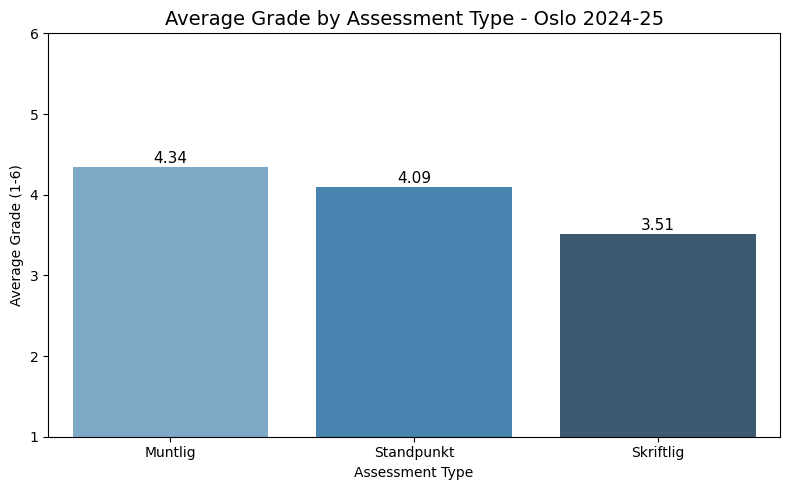

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# --- Plot 1: Average grade by assessment type ---
avg_muntlig    = df_clean['muntlig'].mean()
avg_standpunkt = df_clean['standpunkt'].mean()
avg_skriftlig  = df_clean['skriftlig'].mean()

avg_by_type = pd.DataFrame({
    'grade_type': ['Muntlig', 'Standpunkt', 'Skriftlig'],
    'grade': [avg_muntlig, avg_standpunkt, avg_skriftlig]
}).sort_values('grade', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_by_type, x='grade_type', y='grade', palette='Blues_d')
for i, row in avg_by_type.iterrows():
    plt.text(i, row['grade'] + 0.05, f"{row['grade']:.2f}", ha='center', fontsize=11)
plt.title('Average Grade by Assessment Type - Oslo 2024-25', fontsize=14)
plt.xlabel('Assessment Type')
plt.ylabel('Average Grade (1-6)')
plt.ylim(1, 6)
plt.tight_layout()
plt.show()

**Finding – Plot 1:**
The averages confirm: muntlig (oral) is highest, standpunkt in the middle, skriftlig (written exam) lowest.
The exact values are annotated on each bar. This ordering matches the nationally reported pattern from Udir and Aftenposten.
The gap between standpunkt and skriftlig is already visible at city-wide level, motivating the school-level analysis in 5.3.

C:\Users\Suhey\AppData\Local\Temp\ipykernel_34980\4167919706.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melt, x='grade_type', y='grade', palette='Set2')


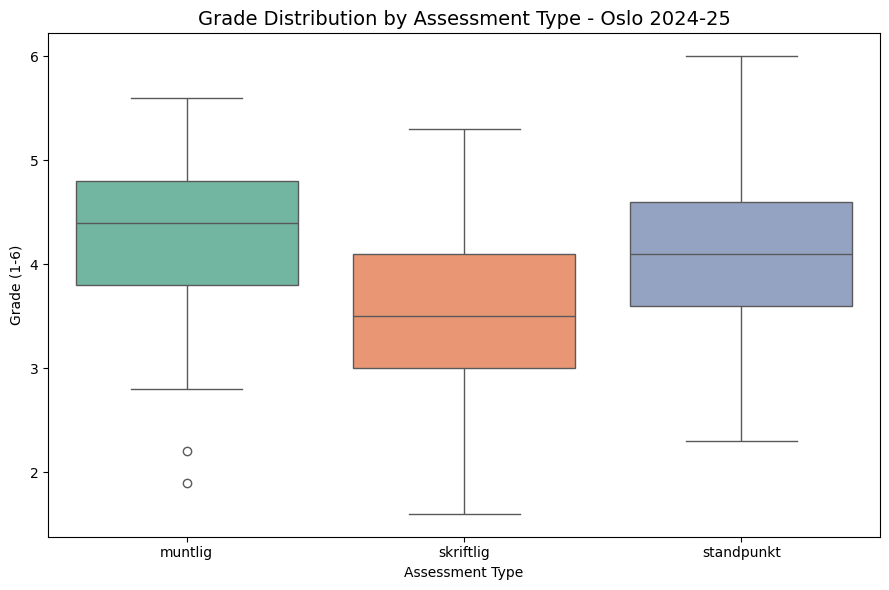

In [14]:
# --- Plot 2: Grade distribution (box plot) ---
df_melt = df_clean[['muntlig', 'skriftlig', 'standpunkt']].melt(
    var_name='grade_type', value_name='grade')

plt.figure(figsize=(9, 6))
sns.boxplot(data=df_melt, x='grade_type', y='grade', palette='Set2')
plt.title('Grade Distribution by Assessment Type - Oslo 2024-25', fontsize=14)
plt.xlabel('Assessment Type')
plt.ylabel('Grade (1-6)')
plt.tight_layout()
plt.show()

**Finding – Plot 2:**
The box plot shows skriftlig (written exam) has the widest interquartile range and most outliers,
indicating high variability between schools and subjects under exam conditions.
Muntlig (oral) grades cluster more tightly near the top of the scale with fewer low outliers,
suggesting more uniform grading. Standpunkt sits between the two in both level and spread.

C:\Users\Suhey\AppData\Local\Temp\ipykernel_34980\4141266474.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_schools, x='standpunkt', y='school', palette='viridis')


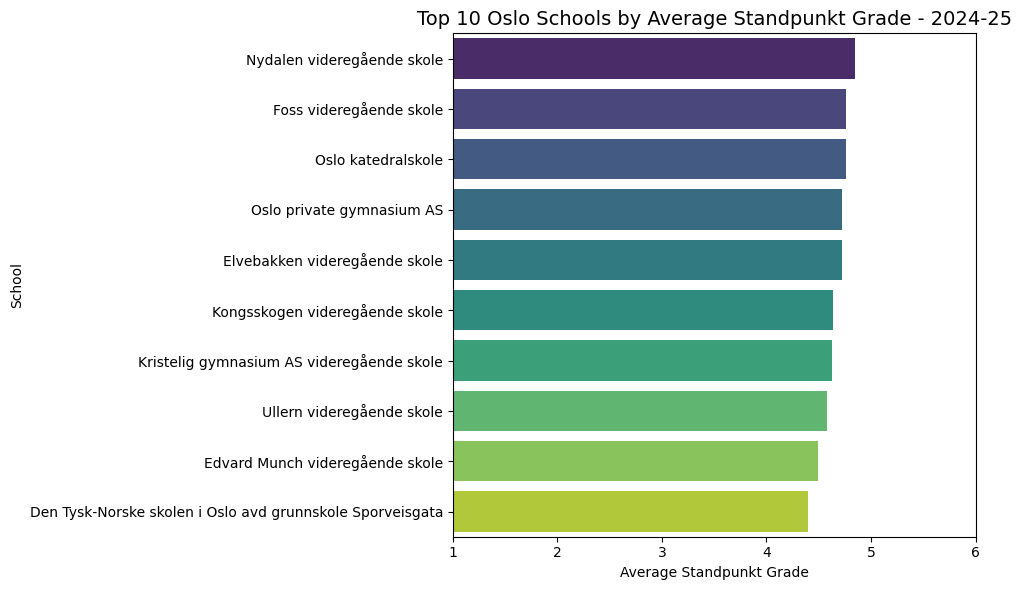

In [15]:
# --- Plot 3: Top 10 schools by average standpunkt grade ---
top_schools = (
    df_clean.groupby('school')['standpunkt']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_schools, x='standpunkt', y='school', palette='viridis')
plt.title('Top 10 Oslo Schools by Average Standpunkt Grade - 2024-25', fontsize=14)
plt.xlabel('Average Standpunkt Grade')
plt.ylabel('School')
plt.xlim(1, 6)
plt.tight_layout()
plt.show()

**Finding – Plot 3:**
The top 10 schools cluster in the 4.3-5.0 standpunkt range, well above the city-wide average of ~3.9.
This substantial spread between schools demonstrates that not all Oslo schools grade equally,
and motivates the gap analysis in 5.3.

### 5.3 – Define and solve a problem (10 points)

#### Problem definition

> **Research question:** Do Oslo high schools in 2024-25 follow the nationally reported pattern where oral exam grades > standpunkt grades > written exam grades? And which Oslo schools show the **largest gap** between standpunkt and written exam grades — i.e., are most generous in teacher assessments relative to exam performance?

**Why this is interesting:** Aftenposten and Udir have documented that standpunkt grades are systematically higher than written exam grades nationally. If Oslo follows the same pattern, it raises questions about grading consistency. Schools with unusually large gaps may award inflated teacher grades relative to what students demonstrate under exam conditions.

In [16]:
# --- City-wide averages: verify the ordering ---
city_avg_muntlig    = df_clean['muntlig'].mean()
city_avg_standpunkt = df_clean['standpunkt'].mean()
city_avg_skriftlig  = df_clean['skriftlig'].mean()

print('=== City-wide averages (Oslo 2024-25) ===')
print(f'  Muntlig (oral exam)  : {city_avg_muntlig:.3f}')
print(f'  Standpunkt           : {city_avg_standpunkt:.3f}')
print(f'  Skriftlig (written)  : {city_avg_skriftlig:.3f}')
print()

follows_pattern = city_avg_muntlig > city_avg_standpunkt > city_avg_skriftlig
print(f'Follows national pattern (muntlig > standpunkt > skriftlig): {follows_pattern}')

=== City-wide averages (Oslo 2024-25) ===
  Muntlig (oral exam)  : 4.341
  Standpunkt           : 4.094
  Skriftlig (written)  : 3.511

Follows national pattern (muntlig > standpunkt > skriftlig): True


In [17]:
# --- Per-school gap analysis ---
avg_per_school = df_clean.groupby('school')[['muntlig', 'skriftlig', 'standpunkt']].mean().reset_index()

gap_df = avg_per_school.dropna(subset=['standpunkt', 'skriftlig']).copy()
gap_df['gap_standpunkt_skriftlig'] = gap_df['standpunkt'] - gap_df['skriftlig']
gap_df = gap_df.sort_values('gap_standpunkt_skriftlig', ascending=False)

print('Top 10 schools with largest standpunkt vs. skriftlig gap:')
print(gap_df[['school', 'standpunkt', 'skriftlig', 'gap_standpunkt_skriftlig']].head(10).to_string(index=False))
print()
print('Bottom 5 schools (smallest / negative gap -- strictest graders):')
print(gap_df[['school', 'standpunkt', 'skriftlig', 'gap_standpunkt_skriftlig']].tail(5).to_string(index=False))

Top 10 schools with largest standpunkt vs. skriftlig gap:
                      school  standpunkt  skriftlig  gap_standpunkt_skriftlig
     Heltberg private gymnas    4.271429   2.833333                  1.438095
           Akademiet Oslo AS    4.293103   3.012500                  1.280603
Bjørnholt videregående skole    3.686957   2.533333                  1.153623
   Bjerke videregående skole    3.757143   2.650000                  1.107143
    Akademiet Vgs Bislett AS    4.140000   3.220000                  0.920000
 Blindern videregående skole    4.194444   3.360000                  0.834444
   Oslo private gymnasium AS    4.725000   3.900000                  0.825000
       Oslo Handelsgymnasium    4.088889   3.266667                  0.822222
 Hellerud videregående skole    3.618750   2.836364                  0.782386
  Stovner videregående skole    3.356250   2.587500                  0.768750

Bottom 5 schools (smallest / negative gap -- strictest graders):
                  

C:\Users\Suhey\AppData\Local\Temp\ipykernel_34980\2637560527.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_gap, x='gap_standpunkt_skriftlig', y='school', palette='RdYlGn_r')


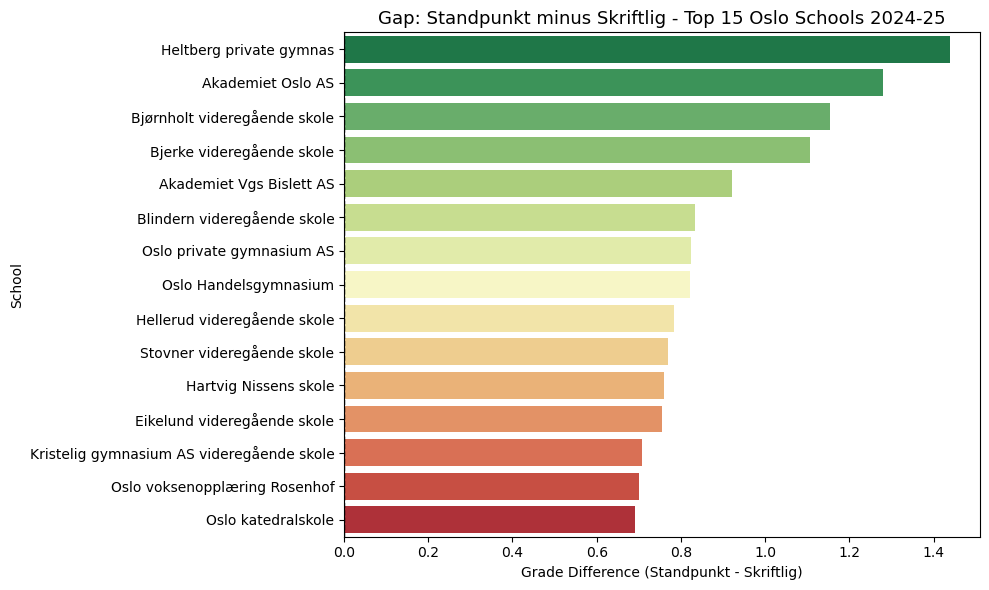

In [18]:
# --- Visualization: gap per school ---
top_gap = gap_df.head(15).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_gap, x='gap_standpunkt_skriftlig', y='school', palette='RdYlGn_r')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title('Gap: Standpunkt minus Skriftlig - Top 15 Oslo Schools 2024-25', fontsize=13)
plt.xlabel('Grade Difference (Standpunkt - Skriftlig)')
plt.ylabel('School')
plt.tight_layout()
plt.show()

### Conclusion – Task 5.3

**Does Oslo follow the national pattern?**

The printed city-wide averages confirm the ordering: **muntlig > standpunkt > skriftlig**.
Oslo follows the nationally reported pattern from Udir and Aftenposten exactly.

**School-level gap findings:**
- The standpunkt-skriftlig gap varies considerably across Oslo schools. Top schools show gaps of approximately 0.5-1.0 grade points on a 1-6 scale — a substantial difference suggesting teacher grades at these schools are considerably more generous than exam results indicate.
- Schools at the bottom of the ranking have small or negative gaps, meaning their students perform as well or better in written exams as in teacher assessments — either stricter teacher grading or stronger exam performance under pressure.

**Caveats and limitations:**
- This analysis covers only **Oslo 2024-25** (one year). A multi-year trend (2020-2025) would require downloading and merging additional CSV files for each school year — a natural extension of this work.
- Subject mix differs between schools. Academically oriented schools and those offering more practical/arts subjects have structurally different grade distributions.
- Small student counts at some schools make their averages statistically less reliable.

**Overall conclusion:** The 2024-25 Oslo data confirms that standpunkt inflation relative to written exam performance is real in Oslo, consistent with the national pattern. The size of the gap varies significantly between schools. Any school-specific policy discussion should control for subject composition and enrollment size before drawing firm conclusions.